In [20]:
!python generate_smiles.py \
             --model paper_checkpoints/ecfp4_with_counts_with_rank \
             --input-smiles examples/smiles.txt \
             --samples 100 \
             --result-path samples.csv

Generated 100 samples in 6.104 seconds.
Valid molecules = 100 / 100
Pearson R = 0.772


In [21]:
import pandas as pd

df = pd.read_csv("samples.csv")
filtered_df = df[(df['tanimoto'] == 1) & (df['is_valid'] == 1)]
filtered_df = filtered_df.sort_values(by='nll', ascending=False).head(6)
filtered_df = filtered_df.drop(columns=['input_smiles', 'nll','is_valid'])
filtered_df.to_csv("modified_samples.csv", index=False)

In [44]:
import subprocess
import pandas as pd

def generate_modified_samples(smiles):
    with open("examples/smiles.txt", 'w') as f:
        f.write(smiles)
    
    command = [
        "python", "generate_smiles.py",
        "--model", "paper_checkpoints/ecfp4_with_counts_with_rank",
        "--input-smiles", "examples/smiles.txt",
        "--samples", "100",
        "--result-path", "samples.csv"
    ]
    
    subprocess.run(command, check=True)

    df = pd.read_csv("samples.csv")
    df['tanimoto'] = df['tanimoto'].round(2)
    df = df[(df['tanimoto'] != 1) & (df['is_valid'] == 1)]
    df = df.sort_values(by='tanimoto', ascending=False)
    selected_rows = []
    last_value = None
    
    for _, row in df.iterrows():
        if last_value is None or row['tanimoto'] <= last_value - 0.02:
            selected_rows.append(row)
            last_value = row['tanimoto']
    
    filtered_df = pd.DataFrame(selected_rows).head(6)
    filtered_df = filtered_df.drop(columns=['input_smiles', 'nll', 'is_valid'], errors='ignore')
    filtered_df.to_csv("modified_samples.csv", index=False)

    print("Modified samples saved to 'modified_samples.csv'")
    return filtered_df

smiles = 'O=C(Cc1ccccc1)NC1C(=O)N2C1SC(C2C(=O)O)(C)C'
generate_modified_samples(smiles)

Generated 100 samples in 6.175 seconds.
Valid molecules = 100 / 100
Pearson R = 0.772
Modified samples saved to 'modified_samples.csv'


,generated_smiles,tanimoto
74,CC(=O)C1N2C(=O)C(NC(=O)Cc3ccccc3)[C@H]2SC1(C)C,0.85
77,CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=S)N2C1C(=O)O,0.83
88,CC1(C)SC2C(NC(=O)COC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O,0.80
91,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,0.78
83,CC1(C)SC2C(NC(=O)c3ccccc3)C(=O)N2C1C(=O)O,0.76
94,CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)OC(C)...,0.74


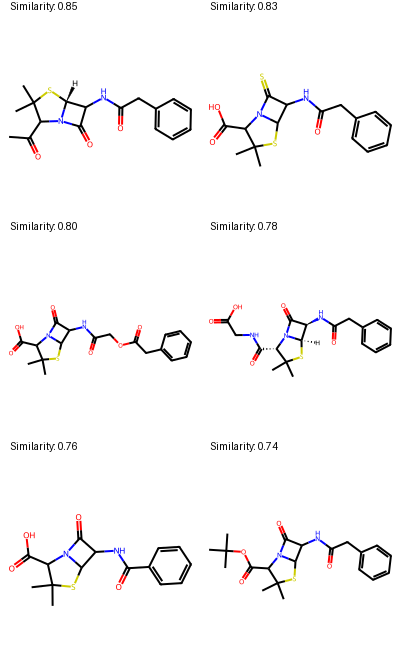

In [45]:
from rdkit import Chem
from rdkit.Chem import Draw
import pandas as pd
from PIL import Image, ImageDraw

def display_smiles_structures(file_path="modified_samples.csv"):
    df = pd.read_csv(file_path)
    smiles_list = df['generated_smiles'].tolist()
    similarity_scores = df['tanimoto'].tolist()
    mols = [Chem.MolFromSmiles(smile) for smile in smiles_list]
    images = [Draw.MolToImage(mol, size=(200, 200)) for mol in mols]
    annotated_images = []
    for img, score in zip(images, similarity_scores):
        img_with_text = Image.new("RGB", (200, 220), "white")
        img_with_text.paste(img, (0, 20))
        draw = ImageDraw.Draw(img_with_text)
        draw.text((10, 0), f"Similarity: {score:.2f}", fill="black")
        annotated_images.append(img_with_text)
    grid_img = Image.new("RGB", (400, 660), "white")
    for i, annotated_img in enumerate(annotated_images):
        row = i // 2
        col = i % 2
        grid_img.paste(annotated_img, (col * 200, row * 220))
    grid_img.show()

display_smiles_structures()


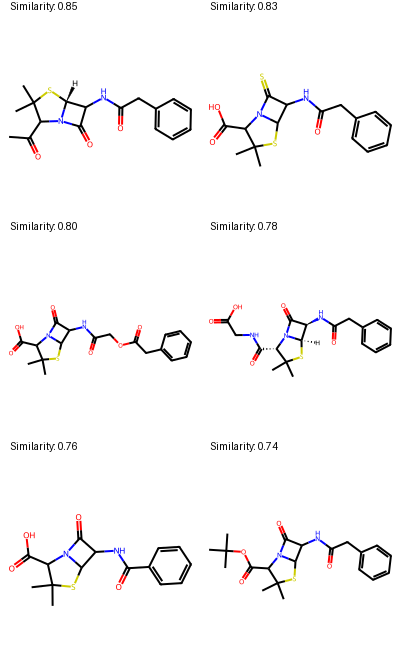

In [46]:
import subprocess
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from PIL import Image, ImageDraw

def generate_and_display_smiles(smiles):
    with open("examples/smiles.txt", 'w') as f:
        f.write(smiles)
    
    command = [
        "python", "generate_smiles.py",
        "--model", "paper_checkpoints/ecfp4_with_counts_with_rank",
        "--input-smiles", "examples/smiles.txt",
        "--samples", "100",
        "--result-path", "samples.csv"
    ]
    
    subprocess.run(command, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=True)

    df = pd.read_csv("samples.csv")
    df['tanimoto'] = df['tanimoto'].round(2)
    df = df[(df['tanimoto'] != 1) & (df['is_valid'] == 1)]
    df = df.sort_values(by='tanimoto', ascending=False)
    selected_rows = []
    last_value = None
    
    for _, row in df.iterrows():
        if last_value is None or row['tanimoto'] <= last_value - 0.02:
            selected_rows.append(row)
            last_value = row['tanimoto']
    
    filtered_df = pd.DataFrame(selected_rows).head(6)
    filtered_df = filtered_df.drop(columns=['input_smiles', 'nll', 'is_valid'], errors='ignore')
    filtered_df.to_csv("modified_samples.csv", index=False)

    smiles_list = filtered_df['generated_smiles'].tolist()
    similarity_scores = filtered_df['tanimoto'].tolist()
    mols = [Chem.MolFromSmiles(smile) for smile in smiles_list]
    images = [Draw.MolToImage(mol, size=(200, 200)) for mol in mols]
    
    annotated_images = []
    for img, score in zip(images, similarity_scores):
        img_with_text = Image.new("RGB", (200, 220), "white")
        img_with_text.paste(img, (0, 20))
        draw = ImageDraw.Draw(img_with_text)
        draw.text((10, 0), f"Similarity: {score:.2f}", fill="black")
        annotated_images.append(img_with_text)
    
    grid_img = Image.new("RGB", (400, 660), "white")
    for i, annotated_img in enumerate(annotated_images):
        row = i // 2
        col = i % 2
        grid_img.paste(annotated_img, (col * 200, row * 220))
    grid_img.show()

smiles = 'O=C(Cc1ccccc1)NC1C(=O)N2C1SC(C2C(=O)O)(C)C'
generate_and_display_smiles(smiles)

In [ ]:
if st.session_state.file_uploaded and st.session_state.gnn_results is not None:
    tabs = st.tabs(["Generate Counterfactuals", "Generate Similar SMILES"])
    
    with tabs[0]:
        sensitizer_smiles = st.session_state.sensitizer_smiles
        if sensitizer_smiles:
            st.markdown("<h4>Select a sensitizer SMILES for counterfactual generation</h4>", unsafe_allow_html=True)
            selected_smiles = st.selectbox("", sensitizer_smiles, index=0, key="select_sensitizer_smiles")
            if st.button("Generate Counterfactuals", key="counterfactual_button"):
                with st.spinner("Generating counterfactuals... Please wait."):
                    generate_exmol_counterfactuals(selected_smiles, model_choice)
                st.session_state.counterfactual_generated = True
        else:
            st.write("No sensitizer SMILES found for counterfactual generation.")

    with tabs[1]:
        nonsensitizer_smiles = st.session_state.nonsensitizer_smiles
        if nonsensitizer_smiles:
            st.markdown("<h4>Select a non-sensitizer SMILES to generate similar structures</h4>", unsafe_allow_html=True)
            selected_smiles = st.selectbox("", nonsensitizer_smiles, index=0, key="select_nonsensitizer_smiles")
            if st.button("Generate Similar SMILES", key="similar_smiles_button"):
                with st.spinner("Generating similar SMILES... Please wait."):
                    generate_and_display_similar_smiles(selected_smiles, model_choice)
        else:
            st.write("No non-sensitizer SMILES found for similar structure generation.")
